Mounted at /content/drive
LOADING RESULTS
✓ ML Results Loaded
✓ DL Results Loaded
✓ Transfer Learning Results Loaded

ALL MODELS COMPARISON
        Model              Type  Accuracy  Precision  Recall  F1-Score
 clinicalbert Transfer Learning     97.73      93.33   66.67     77.78
 roberta_base Transfer Learning     96.32      83.33   47.62     60.61
 biobert_v1.1 Transfer Learning     94.05      50.00   28.57     36.36
       BiLSTM     Deep Learning     90.50       0.20    0.82      0.32
          CNN     Deep Learning     89.25       0.16    0.82      0.26
Random Forest  Machine Learning     81.64      16.35   77.27     26.98
          SVM  Machine Learning     80.24      15.93   81.82     26.67
Decision Tree  Machine Learning     77.45      10.43   54.55     17.52
         LSTM     Deep Learning     50.00       0.04    1.00      0.08

✓ Saved: /content/drive/MyDrive/radiological_report/results/all_models_comparison.csv
✓ Saved: /content/drive/MyDrive/radiological_report/results/all

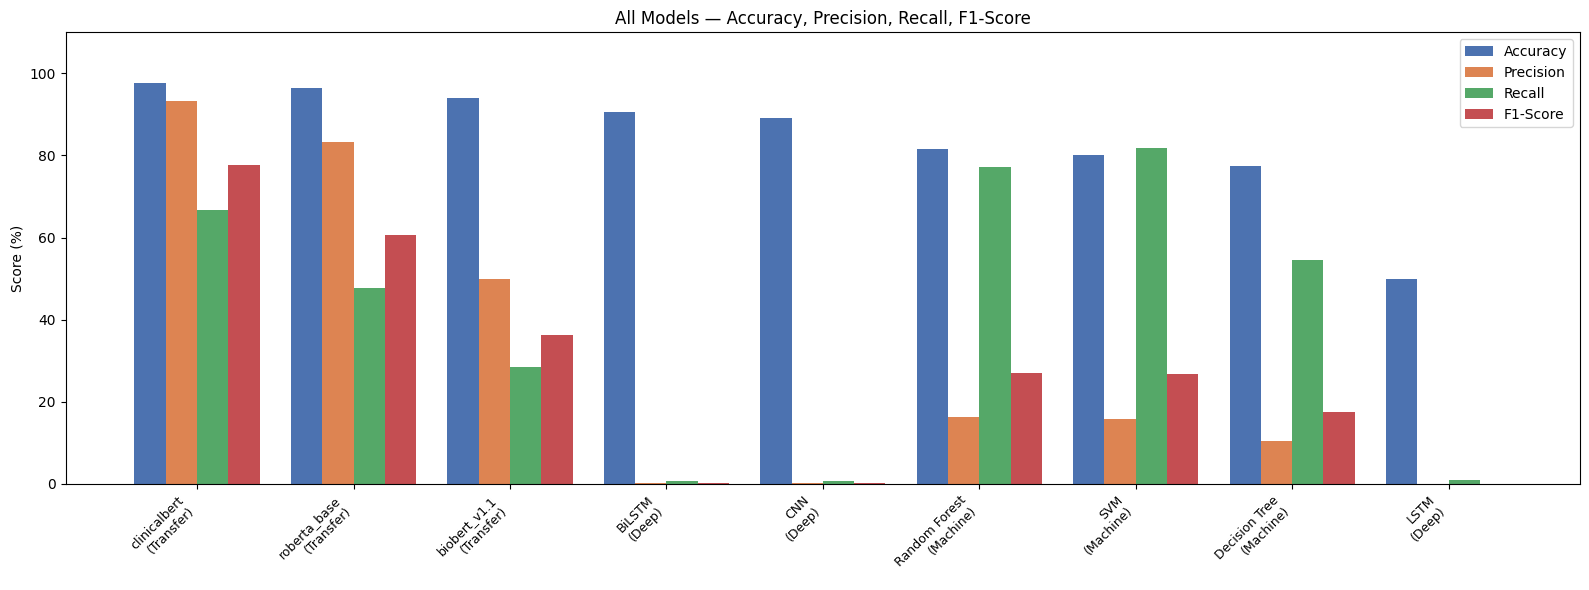

✓ Saved: /content/drive/MyDrive/radiological_report/results/all_metrics_comparison.png


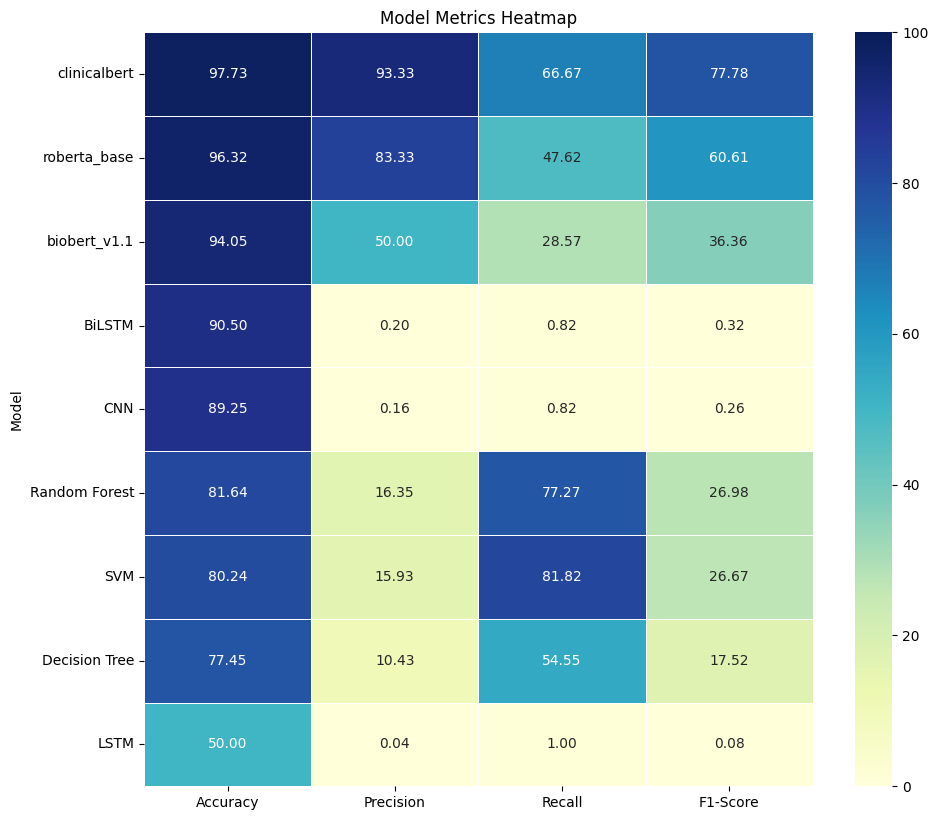

✓ Saved: /content/drive/MyDrive/radiological_report/results/metrics_heatmap.png


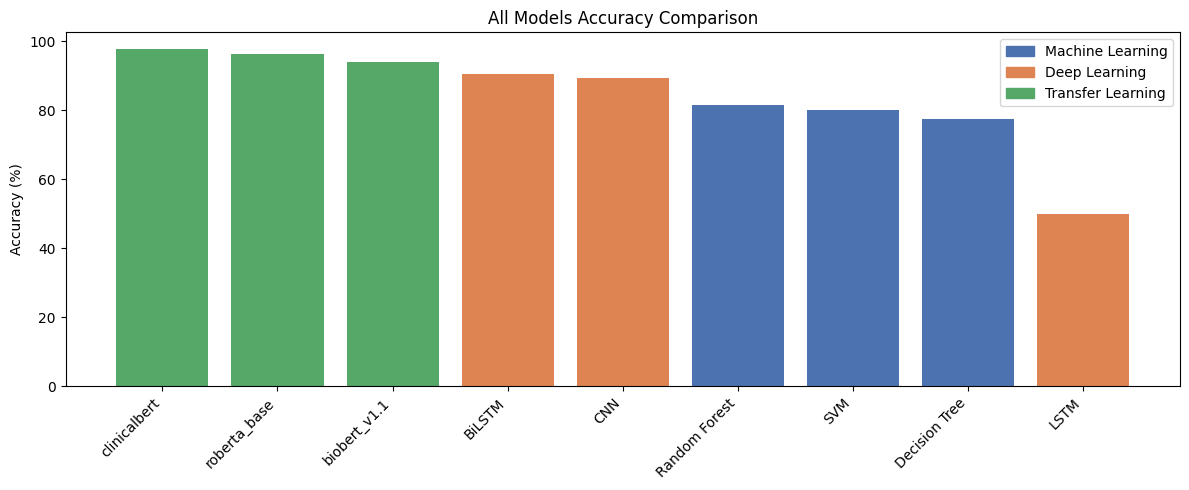

✓ Saved: /content/drive/MyDrive/radiological_report/results/accuracy_comparison.png
✓ Saved: /content/drive/MyDrive/radiological_report/results/final_summary_report.txt

ANALYSIS COMPLETED


In [4]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

!pip install -q pandas openpyxl matplotlib seaborn

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

RESULTS_DIR = "/content/drive/MyDrive/radiological_report/results"

print("="*80)
print("LOADING RESULTS")
print("="*80)

ml_path = os.path.join(RESULTS_DIR, "ml_results.csv")
if os.path.exists(ml_path):
    ml_df = pd.read_csv(ml_path)
    print("✓ ML Results Loaded")
else:
    ml_df = pd.DataFrame()
    print("✗ ML Results Not Found")

dl_path = os.path.join(RESULTS_DIR, "dl_results.csv")
if os.path.exists(dl_path):
    dl_df = pd.read_csv(dl_path)
    print("✓ DL Results Loaded")
else:
    dl_df = pd.DataFrame()
    print("✗ DL Results Not Found")

tl_path = os.path.join(RESULTS_DIR, "tl_results.csv")
if os.path.exists(tl_path):
    tl_df = pd.read_csv(tl_path)
    print("✓ Transfer Learning Results Loaded")
else:
    tl_df = pd.DataFrame()
    print("✗ Transfer Learning Results Not Found")

def safe(row, col, scale=1.0):
    try:
        return round(float(row[col]) * scale, 2)
    except:
        return np.nan

all_results = []

if not ml_df.empty:
    for _, row in ml_df.iterrows():
        all_results.append({
            "Model"    : row["Model"],
            "Type"     : "Machine Learning",
            "Accuracy" : safe(row, "Accuracy"),
            "Precision": safe(row, "Precision"),
            "Recall"   : safe(row, "Recall"),
            "F1-Score" : safe(row, "F1_Score"),
        })

if not dl_df.empty:
    for _, row in dl_df.iterrows():
        all_results.append({
            "Model"    : row["Model"],
            "Type"     : "Deep Learning",
            "Accuracy" : safe(row, "Balanced Acc (%)"),
            "Precision": safe(row, "Precision"),
            "Recall"   : safe(row, "Recall"),
            "F1-Score" : safe(row, "F1-Score"),
        })

if not tl_df.empty:
    for _, row in tl_df.iterrows():
        all_results.append({
            "Model"    : row["Model"],
            "Type"     : "Transfer Learning",
            "Accuracy" : safe(row, "Accuracy",  scale=100),
            "Precision": safe(row, "Precision", scale=100),
            "Recall"   : safe(row, "Recall",    scale=100),
            "F1-Score" : safe(row, "F1-Score",  scale=100),
        })

comparison_df = pd.DataFrame(all_results).sort_values(
    by="Accuracy", ascending=False
).reset_index(drop=True)

print("\n" + "="*80)
print("ALL MODELS COMPARISON")
print("="*80)
print(comparison_df.to_string(index=False))

csv_file   = os.path.join(RESULTS_DIR, "all_models_comparison.csv")
excel_file = os.path.join(RESULTS_DIR, "all_models_comparison.xlsx")
comparison_df.to_csv(csv_file,   index=False)
comparison_df.to_excel(excel_file, index=False)
print(f"\n✓ Saved: {csv_file}")
print(f"✓ Saved: {excel_file}")

best_model = comparison_df.iloc[0]
print("\n" + "="*80)
print("BEST MODEL")
print("="*80)
print(f"  Model    : {best_model['Model']}")
print(f"  Type     : {best_model['Type']}")
print(f"  Accuracy : {best_model['Accuracy']:.2f}%")

metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]
x       = np.arange(len(comparison_df))
width   = 0.2
colors  = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

fig, ax = plt.subplots(figsize=(16, 6))
for i, (metric, color) in enumerate(zip(metrics, colors)):
    ax.bar(x + i * width, comparison_df[metric].fillna(0), width, label=metric, color=color)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(
    [f"{r['Model']}\n({r['Type'].split()[0]})" for _, r in comparison_df.iterrows()],
    rotation=45, ha='right', fontsize=9
)
ax.set_ylabel("Score (%)")
ax.set_title("All Models — Accuracy, Precision, Recall, F1-Score")
ax.legend()
ax.set_ylim(0, 110)
plt.tight_layout()
bar_path = os.path.join(RESULTS_DIR, "all_metrics_comparison.png")
plt.savefig(bar_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"✓ Saved: {bar_path}")

plt.figure(figsize=(10, len(comparison_df) * 0.7 + 2))
sns.heatmap(
    comparison_df.set_index("Model")[metrics].fillna(0),
    annot=True, fmt=".2f", cmap="YlGnBu",
    linewidths=0.5, vmin=0, vmax=100
)
plt.title("Model Metrics Heatmap")
plt.tight_layout()
heatmap_path = os.path.join(RESULTS_DIR, "metrics_heatmap.png")
plt.savefig(heatmap_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"✓ Saved: {heatmap_path}")

colors_type = {"Machine Learning": "#4C72B0", "Deep Learning": "#DD8452", "Transfer Learning": "#55A868"}
plt.figure(figsize=(12, 5))
plt.bar(comparison_df["Model"], comparison_df["Accuracy"],
        color=[colors_type.get(t, "gray") for t in comparison_df["Type"]])
plt.xticks(rotation=45, ha='right')
plt.ylabel("Accuracy (%)")
plt.title("All Models Accuracy Comparison")
from matplotlib.patches import Patch
plt.legend(handles=[Patch(color=v, label=k) for k, v in colors_type.items()])
plt.tight_layout()
acc_path = os.path.join(RESULTS_DIR, "accuracy_comparison.png")
plt.savefig(acc_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"✓ Saved: {acc_path}")

report_file = os.path.join(RESULTS_DIR, "final_summary_report.txt")
with open(report_file, "w") as f:
    f.write("RADIOLOGICAL REPORT CLASSIFICATION\n")
    f.write("="*80 + "\n\n")
    f.write("ALL MODELS RESULTS\n\n")
    f.write(comparison_df.to_string(index=False))
    f.write("\n\nBEST MODEL\n" + "-"*40 + "\n")
    f.write(f"Model    : {best_model['Model']}\n")
    f.write(f"Type     : {best_model['Type']}\n")
    f.write(f"Accuracy : {best_model['Accuracy']:.2f}%\n")
print(f"✓ Saved: {report_file}")

print("\n" + "="*80)
print("ANALYSIS COMPLETED")
print("="*80)
